In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**PassengerId** - У каждого пассажира свой уникальный идентификатор. Каждый идентификатор имеет вид, gggg_ppгде ggggуказывается группа, в которой путешествует пассажир, и ppего номер в группе. Люди в группе часто являются членами семьи, но не всегда.

**HomePlanet** - Планета, с которой пассажир покинул планету, как правило, его планета постоянного проживания.

**CryoSleep** - Указывает, выбрал ли пассажир погружение в анабиоз на время путешествия. Пассажиры в криосне находятся в своих каютах.

**Cabin** - Номер каюты, в которой проживает пассажир. Имеет вид deck/num/side, где sideможет означать либо P« порт» , либо S«правый борт» .

**Destination** - Планета, на которую прибудет пассажир.

**Age** - Возраст пассажира.

**VIP** - Оплатил ли пассажир специальные VIP-услуги во время путешествия.

**RoomService, FoodCourt, ShoppingMall, Spa, VRDeck** - Сумма, которую пассажир выставил счет за пользование каждой из многочисленных роскошных услуг космического корабля «Титаник» .

**Name** - Имя и фамилия пассажира.

**Transported** — Был ли пассажир перенесён в другое измерение. Это целевой показатель, столбец, который вы пытаетесь предсказать.

# Обработка данных

## Загрузка данных

In [21]:
df = pd.read_csv('train.csv')

In [100]:
df.sample(5)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
6399,6760_01,Mars,False,F/1404/P,PSO J318.5-22,30.0,False,51.0,0.0,1373.0,0.0,5.0,Shex Pri,True
3370,3624_01,NaN,False,G/594/P,TRAPPIST-1e,29.0,False,0.0,0.0,0.0,0.0,0.0,Dawne Tranklinay,False
8313,8872_01,Mars,True,F/1828/P,TRAPPIST-1e,23.0,False,0.0,0.0,0.0,0.0,0.0,Rinnab Surry,True
5844,6184_01,Earth,True,G/1003/S,PSO J318.5-22,4.0,False,0.0,0.0,0.0,0.0,0.0,Kimmie Lopelases,True
7887,8419_01,Earth,False,F/1618/S,TRAPPIST-1e,19.0,False,0.0,168.0,481.0,0.0,0.0,Fanna Mosepherry,True


## Первичный анализ

In [91]:
df.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [92]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


## Заполнение пустых строк, fe

HomePlanet - смотреть на группы по PassengerId, возможно есть с одной группы и тогда их соединять и дописывать. Также можно смотреть на Name, мб фамилии одинаковые. Еще вариант проверить Cabin

CryoSleep - если пользовался чем-то из сервиса (RoomService, FoodCourt, ShoppingMall, Spa, VRDeck), то значит не спал и равно False. Если всё в нулях, то True

Cabin - 

Destination - аналогично с HomePlanet

Age - заполнять медианной разбитой по группкам. Как вариант по PassengerId вытащить группу и из нее группу, потом посмотреть на Name, мб фамилия подскажет, 

VIP - 

Траты просто суммировать в единую группу

Name - посмотреть по группам из PassengerId, если что просто отбросить, мб не получится инфу добыть

### PassengerId -> group и groupSize

In [22]:
df['group'] =  df['PassengerId'].str.findall(r'[\d]{4}').str.join('')

In [23]:
df['groupSize'] = df.groupby('group')['group'].transform('count')

### Траты (объединение RoomService, FoodCourt, ShoppingMall, Spa, VRDeck)

In [26]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df['expense'] = df[spend_cols].sum(axis=1, min_count=1)
df['expense'] = df['expense'].fillna(0)

### CryoSleep в пустых строках считаю, что спал, если не тратил деньг

In [27]:
df.loc[df['CryoSleep'].isna() & (df['expense'] > 0), 'CryoSleep'] = False
df.loc[df['CryoSleep'].isna() & (df['expense'] == 0), 'CryoSleep'] = True

### Корреляция трат от возраста

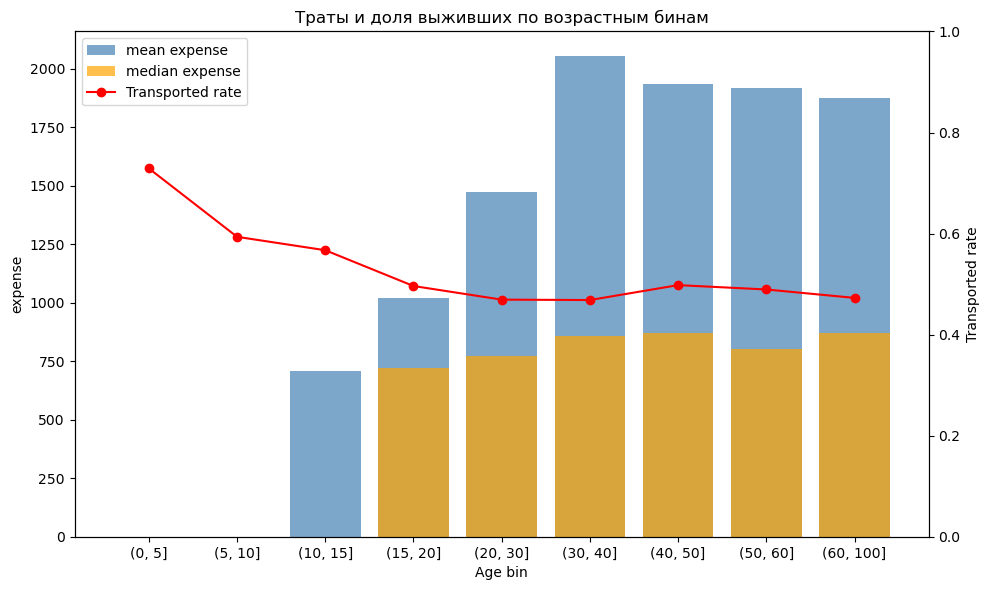

In [28]:
df['age_bin'] = pd.cut(df['Age'], bins=[0, 5, 10, 15, 20, 30, 40, 50, 60, 100])

agg = df.groupby('age_bin', observed=True).agg(
    mean_expense=('expense', 'mean'),
    median_expense=('expense', 'median'),
    transport_rate=('Transported', 'mean'),
    n=('expense', 'size')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(
    agg['age_bin'].astype(str),
    agg['mean_expense'],
    color='steelblue',
    alpha=0.7,
    label='mean expense'
)
ax1.bar(
    agg['age_bin'].astype(str),
    agg['median_expense'],
    color='orange',
    alpha=0.7,
    label='median expense'
)
ax1.set_ylabel('expense')
ax1.set_xlabel('Age bin')

ax2 = ax1.twinx()
ax2.plot(
    agg['age_bin'].astype(str),
    agg['transport_rate'],
    color='red',
    marker='o',
    label='Transported rate'
)
ax2.set_ylabel('Transported rate')
ax2.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Траты и доля выживших по возрастным бинам')
plt.tight_layout()
plt.show()

По графику видно, что до 8 лет нет никаких трат, следовательно, можно дозаполнить пустые expense. Если age<8, то expense = 0

In [234]:
df['expense'] = np.where(df['Age'] < 8, 0, df['expense'])

У остальных считаем, что трат не было, все Nan заменяем на ноль

In [ ]:
df['expense'] = df['expense'].fillna(0)

### expense заполненние Nan нуляем, если CryoSleep == True

In [29]:
df['expense'] = np.where(df['CryoSleep'] == True, 0, df['expense'])

### Name и Surname

In [30]:
df['Surname'] = df['Name'].str.findall(r'^\S+\s+(\S+)').str.join('')
df['Surname'] = df.groupby('group')['Surname'].transform(
    lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
)
df['Name'] = df['Name'].str.findall(r'^\S+').str.join('')

### Заполнение HomePlanet на основе популярного по группировке по group и Surname

In [31]:
df['HomePlanet'] = df.groupby(['group', 'Surname'], dropna=False)['HomePlanet'].transform(fill_mode)

### Заполнение HomePlanet на основе популярного по группировке по group

In [32]:
df['HomePlanet'] = df.groupby(['group'], dropna=False)['HomePlanet'].transform(fill_mode)

### Заполнение Destination на основе популярного по группировке по group и Surname

In [33]:
df['Destination'] = df.groupby(['group', 'Surname','Cabin'], dropna=False)['Destination'].transform(fill_mode)

### Заполнение Cabin на основе популярного по группировке по group

In [34]:
df['Cabin'] = df.groupby(['group'], dropna=False)['Cabin'].transform(fill_mode)

In [35]:
df['deck'] = df['Cabin'].str.split('/').str[0]
df['num'] = df['Cabin'].str.split('/').str[1]
df['side'] = df['Cabin'].str.split('/').str[2]

df['deck'] = df.groupby('group', dropna=False)['deck'].transform(fill_mode)
df['deck'] = df['deck'].fillna(df['deck'].mode().iloc[0])

df['side'] = df.groupby('group', dropna=False)['side'].transform(fill_mode)
df['side'] = df.groupby('deck', dropna=False)['side'].transform(fill_mode)
df['side'] = df['side'].fillna(df['side'].mode().iloc[0])

df['num'] = pd.to_numeric(df['num'], errors='coerce')
df['num'] = df.groupby(['group','deck'], dropna=False)['num'].transform(
    lambda x: x.fillna(x.median()))
df['num'] = df.groupby('deck', dropna=False)['num'].transform(
    lambda x: x.fillna(x.median()))
df['num'] = df['num'].fillna(df['num'].median())

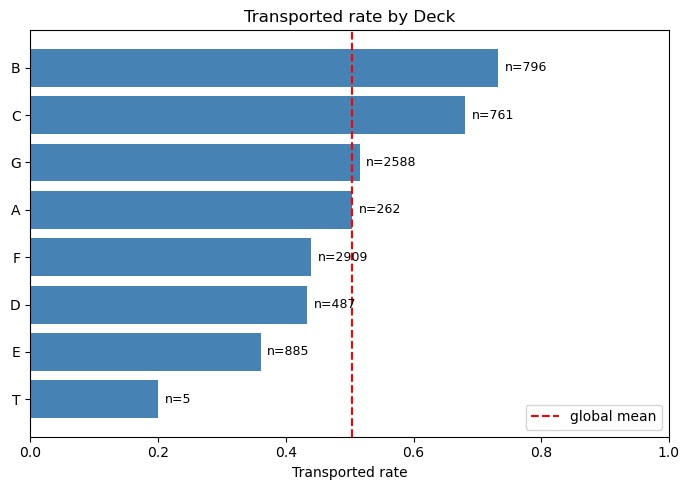

In [36]:
rate_deck = df.groupby('deck', dropna=False)['Transported'].agg(['mean','count'])
rate_deck = rate_deck.sort_values('mean')

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(rate_deck.index.astype(str), rate_deck['mean'], color='steelblue')
for i, (m, c) in enumerate(zip(rate_deck['mean'], rate_deck['count'])):
    ax.text(m + 0.01, i, f'n={c}', va='center', fontsize=9)
ax.axvline(df['Transported'].mean(), color='red', ls='--', label='global mean')
ax.set_xlim(0, 1)
ax.set_xlabel('Transported rate')
ax.set_title('Transported rate by Deck')
ax.legend()
plt.tight_layout()
plt.show()

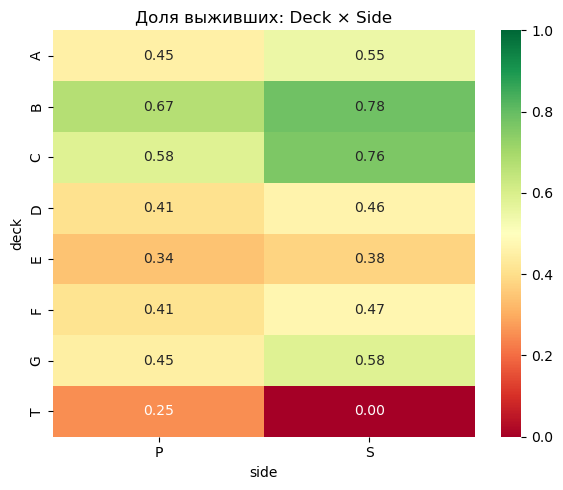

In [37]:
pivot = df.pivot_table(
    index='deck', columns='side',
    values='Transported', aggfunc='mean'
)

plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1)
plt.title('Доля выживших: Deck × Side')
plt.tight_layout()
plt.show()

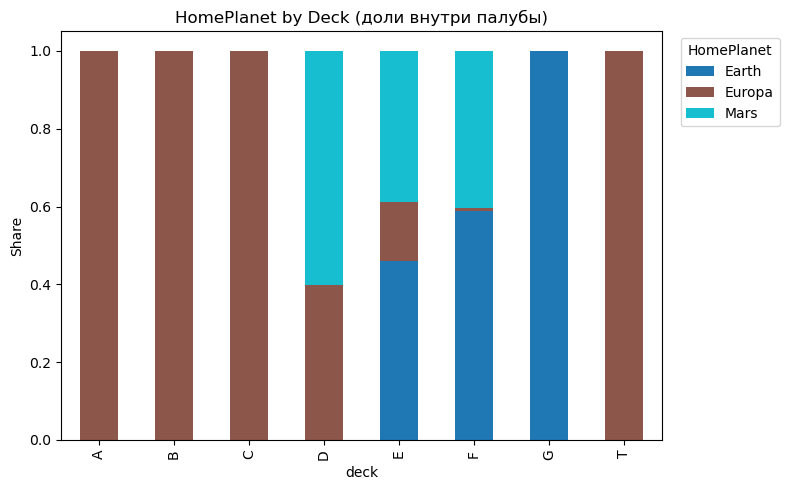

HomePlanet  Earth  Europa  Mars
deck                           
A               0     261     0
B               0     795     0
C               0     757     0
D               0     192   291
E             403     131   340
F            1684      21  1156
G            2547       0     0
T               0       4     0


In [39]:
ct = pd.crosstab(df['deck'], df['HomePlanet'], normalize='index')
ct = ct.sort_index()

ct.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='tab10')
plt.title('HomePlanet by Deck (доли внутри палубы)')
plt.ylabel('Share')
plt.legend(title='HomePlanet', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(pd.crosstab(df['deck'], df['HomePlanet']))

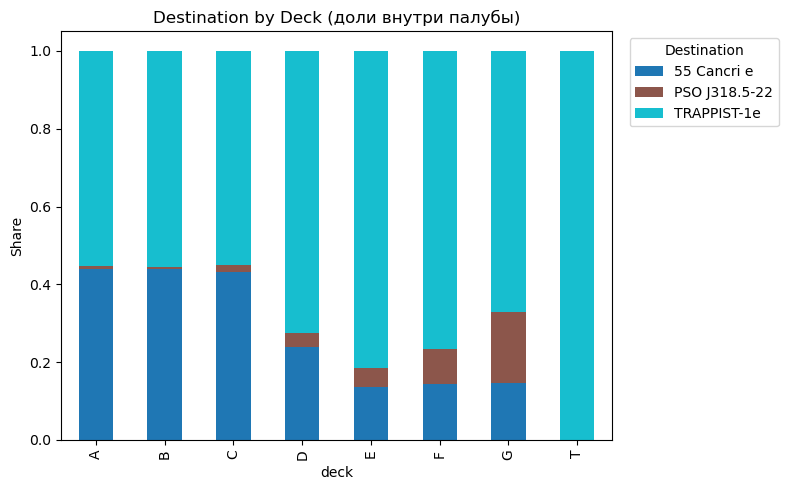

Destination  55 Cancri e  PSO J318.5-22  TRAPPIST-1e
deck                                                
A                    114              2          144
B                    347              3          439
C                    325             14          415
D                    115             17          347
E                    118             42          705
F                    400            243         2115
G                    373            466         1714
T                      0              0            5


In [269]:
ct = pd.crosstab(df['deck'], df['Destination'], normalize='index')
ct = ct.sort_index()

ct.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='tab10')
plt.title('Destination by Deck (доли внутри палубы)')
plt.ylabel('Share')
plt.legend(title='Destination', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(pd.crosstab(df['deck'], df['Destination']))

Исходя из графиков можно сделать вывод, что от зависимости палубы были шансы выжить, но A не значит, что самый наивысший шанс выживания.
Также видно, что HomePlanet для A, B, C, T является Europa. Для G и большей части F - Earth.
Помимо этого для Destination в T однозначно Trappist-1e.

In [40]:
df.loc[df['HomePlanet'].isna() & df['deck'].isin(['A','B','C','T']), 'HomePlanet'] = 'Europa'
df.loc[df['HomePlanet'].isna() & (df['deck'] == 'G'), 'HomePlanet'] = 'Earth'
df['HomePlanet'] = df.groupby('deck', dropna=False)['HomePlanet'].transform(fill_mode)
df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode().iloc[0])

df.loc[df['Destination'].isna() & (df['deck'] == 'T'), 'Destination'] = 'TRAPPIST-1e'
df['Destination'] = df['Destination'].fillna(df['Destination'].mode().iloc[0])

### VIP, по ним ничего не сделаешь, заполняем False, т.к. гораздо больше перевес

In [41]:
df['VIP'].value_counts()

VIP
False    8291
True      199
Name: count, dtype: int64

In [42]:
df['VIP'] = df['VIP'].astype('boolean').fillna(False)

#### Проверка на выбросы

##### Age

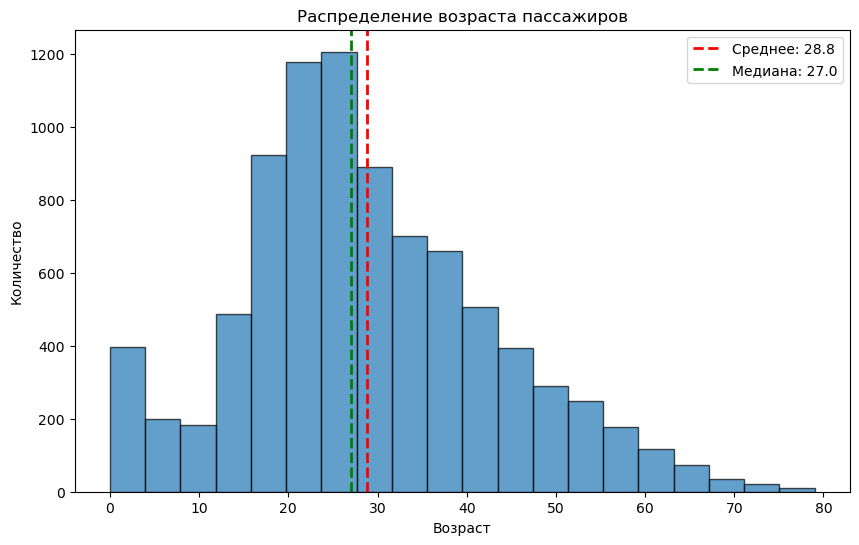

In [46]:
plt.figure(figsize=(10,6))
plt.hist(df['Age'].dropna(), bins=20, edgecolor='black', alpha=0.7)

plt.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {df["Age"].mean():.1f}')
plt.axvline(df['Age'].median(), color='green', linestyle='--', linewidth=2, label=f'Медиана: {df["Age"].median():.1f}')

plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.title('Распределение возраста пассажиров')
plt.legend()
plt.show()

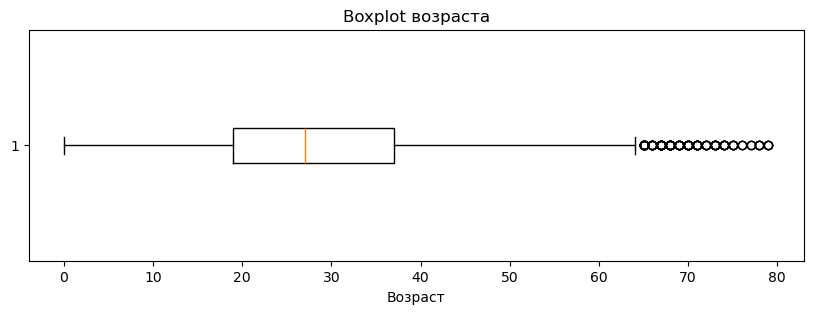

In [47]:
plt.figure(figsize=(10, 3))
plt.boxplot(df['Age'].dropna(), vert=False)
plt.xlabel('Возраст')
plt.title('Boxplot возраста')
plt.show()

##### Expense

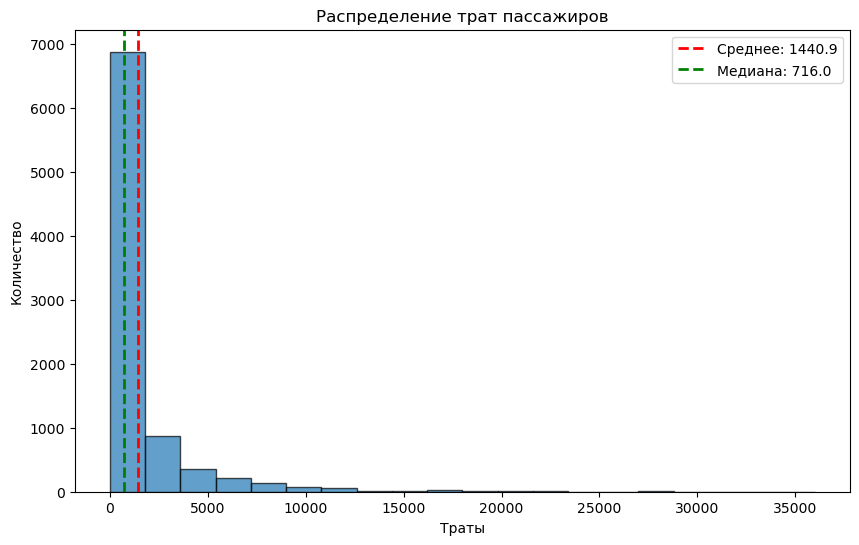

In [56]:
plt.figure(figsize=(10,6))
plt.hist(df['expense'].dropna(), bins=20, edgecolor='black', alpha=0.7)

plt.axvline(df['expense'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {df["expense"].mean():.1f}')
plt.axvline(df['expense'].median(), color='green', linestyle='--', linewidth=2, label=f'Медиана: {df["expense"].median():.1f}')

plt.xlabel('Траты')
plt.ylabel('Количество')
plt.title('Распределение трат пассажиров')
plt.legend()
plt.show()

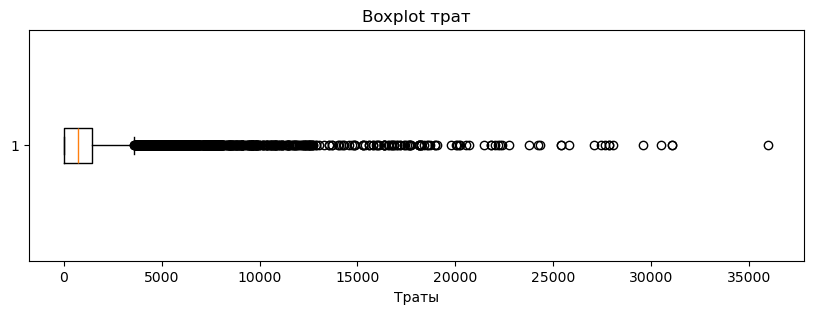

In [57]:
plt.figure(figsize=(10, 3))
plt.boxplot(df['expense'].dropna(), vert=False)
plt.xlabel('Траты')
plt.title('Boxplot трат')
plt.show()

Выбросов на самом деле немного, не вижу смысла сейчас удалять данные.

На этом идеи обработки пустых значений заканчиваются и наступает процесс к тестированию моделей и доработки новых фичей

#### Сбор предыдущих шагов в единое

In [74]:
def fill_mode(x):
    return x.fillna(x.mode().iloc[0]) if not x.mode().empty else x

df = pd.read_csv('train.csv')

df['group'] = df['PassengerId'].str.split('_').str[0]
df['groupSize'] = df.groupby('group')['group'].transform('count')

spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df['expense'] = df[spend_cols].sum(axis=1, min_count=1)
df['expense'] = df['expense'].fillna(0)

df.loc[df['CryoSleep'].isna() & (df['expense'] > 0), 'CryoSleep'] = False
df.loc[df['CryoSleep'].isna() & (df['expense'] == 0), 'CryoSleep'] = True

df['expense'] = np.where(df['CryoSleep'] == True, 0, df['expense'])
df['expense'] = np.where(df['Age'] < 8, 0, df['expense'])

df['Surname'] = df['Name'].str.split().str[-1]
df['Surname'] = df.groupby('group')['Surname'].transform(
    lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)
df['Name'] = df['Name'].str.split().str[0]

df['Cabin'] = df.groupby(['group'], dropna=False)['Cabin'].transform(fill_mode)
df['deck'] = df['Cabin'].str.split('/').str[0]
df['num'] = df['Cabin'].str.split('/').str[1]
df['side'] = df['Cabin'].str.split('/').str[2]

df['deck'] = df.groupby('group', dropna=False)['deck'].transform(fill_mode)
df['deck'] = df['deck'].fillna(df['deck'].mode().iloc[0])

df['side'] = df.groupby('group', dropna=False)['side'].transform(fill_mode)
df['side'] = df.groupby('deck', dropna=False)['side'].transform(fill_mode)
df['side'] = df['side'].fillna(df['side'].mode().iloc[0])


df['num'] = pd.to_numeric(df['num'], errors='coerce')

df['num'] = df.groupby('group', dropna=False)['num'].transform(lambda x: x.fillna(x.median()))
df['num'] = df.groupby('deck', dropna=False)['num'].transform(lambda x: x.fillna(x.median()))
df['num'] = df['num'].fillna(df['num'].median())

df.loc[df['HomePlanet'].isna() & df['deck'].isin(['A','B','C','T']), 'HomePlanet'] = 'Europa'
df.loc[df['HomePlanet'].isna() & (df['deck'] == 'G'), 'HomePlanet'] = 'Earth'
df['HomePlanet'] = df.groupby('deck', dropna=False)['HomePlanet'].transform(fill_mode)
df['HomePlanet'] = df.groupby(['group', 'Surname'], dropna=False)['HomePlanet'].transform(fill_mode)
df['HomePlanet'] = df.groupby(['group'], dropna=False)['HomePlanet'].transform(fill_mode)
df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode().iloc[0])

df.loc[df['Destination'].isna() & (df['deck'] == 'T'), 'Destination'] = 'TRAPPIST-1e'
df['Destination'] = df.groupby(['group', 'Surname','Cabin'], dropna=False)['Destination'].transform(fill_mode)
df['Destination'] = df['Destination'].fillna(df['Destination'].mode().iloc[0])


df['VIP'] = df['VIP'].astype('boolean').fillna(False)

df['Age'] = df.groupby('group', dropna=False)['Age'].transform(lambda x: x.fillna(x.median()))
df['Age'] = df['Age'].fillna(df['Age'].median())


df = df.drop(columns=['PassengerId', 'Name', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Cabin', 'Surname', 'group'])

## Отбор признаков

Разбиваем данные на количественные, бинарные и категориальные

In [77]:
numeric_cols = ['Age', 'groupSize', 'expense', 'num']
category_cols = ['HomePlanet', 'Destination', 'deck', 'CryoSleep', 'VIP', 'side']

## Обучение моделей

### 0) Препроцессинг

In [16]:
from sklearn.compose import ColumnTransformer

In [78]:
X = df.drop(columns=['Transported'])
y = df['Transported'].astype(int)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore'), category_cols)
])

### 1) KNN

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [20]:
pipe = Pipeline([
    ('prep', preprocessor),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'KNN: {scores.mean():.4f} ± {scores.std():.4f}')

KNN: 0.7194 ± 0.0045


#### 1.1 KNN Поиск лучших параметров через GridSearchCV

In [69]:
from sklearn.model_selection import GridSearchCV

In [70]:
pipe = Pipeline([
    ('prep', preprocessor),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
])

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan'],
}

grid_search = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=5, n_jobs=-1)
grid_search.fit(X, y)

print('KNeighborsClassifier, GridSearchCV')
print('Лучшие параметры :', grid_search.best_params_)
print('Лучшая точность:', grid_search.best_score_)

KNeighborsClassifier, GridSearchCV
Лучшие параметры : {'knn__metric': 'manhattan', 'knn__n_neighbors': 9, 'knn__weights': 'uniform'}
Лучшая точность: 0.7250678438397264


#### 1.2 KNN Поиск лучших параметров через Optuna

In [71]:
import optuna
from optuna.integration import OptunaSearchCV
import warnings
from optuna.exceptions import ExperimentalWarning

In [72]:
warnings.filterwarnings('ignore', category=ExperimentalWarning)
warnings.filterwarnings('ignore', category=FutureWarning, module='optuna_integration')
warnings.filterwarnings('ignore', category=FutureWarning, module='optuna')

optuna.logging.set_verbosity(optuna.logging.WARNING)


pipe = Pipeline([
    ('prep', preprocessor),
    ('knn', KNeighborsClassifier()),
])

param_distributions = {
    'knn__n_neighbors': optuna.distributions.IntDistribution(3, 15),
    'knn__weights': optuna.distributions.CategoricalDistribution(['uniform', 'distance']),
    'knn__metric': optuna.distributions.CategoricalDistribution(['euclidean', 'manhattan']),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
optuna_search = OptunaSearchCV(estimator=pipe, param_distributions=param_distributions, n_trials=50, cv=cv,
                                scoring='accuracy', n_jobs=-1, random_state=42, verbose=1)

optuna_search.fit(X, y)

print('KNeighborsClassifier, Optuna')
print('Лучшие параметры:', optuna_search.best_params_)
print('Лучшая точность:', optuna_search.best_score_)

KNeighborsClassifier, Optuna
Лучшие параметры: {'knn__n_neighbors': 14, 'knn__weights': 'uniform', 'knn__metric': 'manhattan'}
Лучшая точность: 0.7428960336582205


### 2) LogisticRegression

In [73]:
from sklearn.linear_model import LogisticRegression

In [79]:
pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(random_state=42, max_iter=1000)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'LogReg: {scores.mean():.4f} ± {scores.std():.4f}')

LogReg: 0.7306 ± 0.0090


#### 2.1) LogisticRegression L1/Lasso

In [80]:
pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'LogReg: {scores.mean():.4f} ± {scores.std():.4f}')

LogReg: 0.7307 ± 0.0090


#### 2.2) LogisticRegression L2/Ridge 

In [81]:
for C_val in [0.001, 0.01, 0.1, 1.0, 10.0]:
    pipe = Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(penalty='l2', C=C_val, max_iter=1000, random_state=42)),
    ])
    score = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1).mean()
    print(f'C={C_val}: {score:.4f}')

C=0.001: 0.7340
C=0.01: 0.7353
C=0.1: 0.7310
C=1.0: 0.7306
C=10.0: 0.7309


#### 2.3) LogisticRegression ElasticNet

In [82]:
pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, random_state=42, max_iter=1000)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'LogReg: {scores.mean():.4f} ± {scores.std():.4f}')

LogReg: 0.7306 ± 0.0087


### 3) Решающее дерево

In [75]:
from sklearn.tree import DecisionTreeClassifier

In [76]:
pipe = Pipeline([
    ('prep', preprocessor),
    ('dtс', DecisionTreeClassifier(random_state=42)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'DecisionTreeClassifier: {scores.mean():.4f} ± {scores.std():.4f}')

DecisionTreeClassifier: 0.6758 ± 0.0120


### 4) Random Forest 

In [77]:
from sklearn.ensemble import RandomForestClassifier

In [78]:
pipe = Pipeline([
    ('prep', preprocessor),
    ('rfc', RandomForestClassifier(random_state=42)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'RandomForestClassifier: {scores.mean():.4f} ± {scores.std():.4f}')

RandomForestClassifier: 0.7435 ± 0.0085


#### 4.1 RandomForestClassifier Поиск лучших параметров через GridSearchCV

In [79]:
pipe = Pipeline([
    ('prep', preprocessor),
    ('rfc', RandomForestClassifier(random_state=42)),
])

param_grid = {
    'rfc__n_estimators': [200, 500],
    'rfc__max_depth': [None, 10, 20],
    'rfc__min_samples_split': [2, 5],
    'rfc__min_samples_leaf': [1, 2],
    'rfc__max_features': ['sqrt', 'log2'],
}

grid_search = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=5, n_jobs=-1)
grid_search.fit(X, y)

print('RandomForestClassifier, GridSearchCV')
print('Лучшие параметры:', grid_search.best_params_)
print('Лучшая точность:', grid_search.best_score_)

RandomForestClassifier, GridSearchCV
Лучшие параметры: {'rfc__max_depth': 10, 'rfc__max_features': 'sqrt', 'rfc__min_samples_leaf': 2, 'rfc__min_samples_split': 5, 'rfc__n_estimators': 500}
Лучшая точность: 0.7447419948901232


#### 4.2 RandomForestClassifier Поиск лучших параметров через Optuna

In [82]:
warnings.filterwarnings('ignore', category=ExperimentalWarning)
warnings.filterwarnings('ignore', category=FutureWarning, module='optuna_integration')
warnings.filterwarnings('ignore', category=FutureWarning, module='optuna')

optuna.logging.set_verbosity(optuna.logging.WARNING)


pipe = Pipeline([
    ('prep', preprocessor),
    ('rfc', RandomForestClassifier(random_state=42)),
])

param_distributions = {
    'rfc__n_estimators': optuna.distributions.IntDistribution(100, 1000, step=100),
    'rfc__max_depth': optuna.distributions.CategoricalDistribution([None, 10, 15, 20, 30]),
    'rfc__min_samples_split': optuna.distributions.IntDistribution(2, 20),
    'rfc__min_samples_leaf': optuna.distributions.IntDistribution(1, 10),
    'rfc__max_features': optuna.distributions.CategoricalDistribution(['sqrt', 'log2']),
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
optuna_search = OptunaSearchCV(estimator=pipe, param_distributions=param_distributions, n_trials=50, cv=cv,
                                scoring='accuracy', n_jobs=-1, random_state=42, verbose=1)

optuna_search.fit(X, y)

print('RandomForestClassifier, Optuna')
print('Лучшие параметры:', optuna_search.best_params_)
print('Лучшая точность:', optuna_search.best_score_)

RandomForestClassifier, Optuna
Лучшие параметры: {'rfc__n_estimators': 800, 'rfc__max_depth': 30, 'rfc__min_samples_split': 6, 'rfc__min_samples_leaf': 7, 'rfc__max_features': 'sqrt'}
Лучшая точность: 0.760841945194221


### 5 Бустинги

#### 5.1 CatBoost

In [99]:
from catboost import CatBoostClassifier, Pool, cv
from sklearn.model_selection import StratifiedKFold

In [108]:
X_cb = X.copy()
for c in X_cb.columns:
    if X_cb[c].dtype == 'boolean':
        X_cb[c] = X_cb[c].astype(int)


cat_cols = ['HomePlanet', 'Destination', 'deck', 'CryoSleep', 'side']
for c in cat_cols:
    X_cb[c] = X_cb[c].astype(str).astype('category').cat.codes

pipe = Pipeline([
    ('cat', CatBoostClassifier(iterations=1000, depth=6, learning_rate=0.05, l2_leaf_reg=3, random_seed=42, verbose=0,task_type='GPU')),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X_cb, y, cv=cv, scoring='accuracy', n_jobs=1)
print(f'CatBoost: {scores.mean():.4f} ± {scores.std():.4f}')

CatBoost: 0.7626 ± 0.0031


#### 5.1.1 CatBoost лучшие параметры

In [97]:
X_cb = X.copy()
for c in X_cb.columns:
    if X_cb[c].dtype == 'boolean':
        X_cb[c] = X_cb[c].astype(int)

cat_features = ['HomePlanet', 'Destination', 'deck', 'CryoSleep', 'side']
train_pool = Pool(data=X_cb, label=y, cat_features=cat_features)

params = {
    'iterations': 1000,
    'task_type':'CPU',
    'depth': 6,
    'learning_rate': 0.05,
    'l2_leaf_reg': 3,
    'random_seed': 42,
    'verbose': 0,
    'eval_metric': 'Accuracy',
    'loss_function': 'Logloss',
}

cv_results = cv(pool=train_pool, params=params, fold_count=5,stratified=True,
                shuffle=True, seed=42, verbose=False)

mean_accuracy = cv_results['test-Accuracy-mean'].iloc[-1]
std_accuracy  = cv_results['test-Accuracy-std'].iloc[-1]
print(f'CatBoost: {mean_accuracy:.4f} ± {std_accuracy:.4f}')

Training on fold [0/5]
bestTest = 0.780333525
bestIteration = 812
Training on fold [1/5]
bestTest = 0.7688326624
bestIteration = 724
Training on fold [2/5]
bestTest = 0.7590569293
bestIteration = 216
Training on fold [3/5]
bestTest = 0.7675489068
bestIteration = 960
Training on fold [4/5]
bestTest = 0.7560414269
bestIteration = 859
Baseline CatBoost: 0.7638 ± 0.0108


#### 5.2 LightGBM

In [102]:
from lightgbm import LGBMClassifier

In [103]:
pipe = Pipeline([
    ('prep', preprocessor),
    ('lgbm', LGBMClassifier(random_state=42, verbose=-1)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'LGBMClassifier: {scores.mean():.4f} ± {scores.std():.4f}')

LGBMClassifier: 0.7573 ± 0.0048


#### 5.3 XGBoost

In [109]:
from xgboost import XGBClassifier

In [110]:
pipe = Pipeline([
    ('prep', preprocessor),
    ('xgb', XGBClassifier(random_state=42, verbosity=0)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'XGBClassifier: {scores.mean():.4f} ± {scores.std():.4f}')

XGBClassifier: 0.7451 ± 0.0069


## Итоги до FE

На данный момент таблица результатов выглядит следующим образом

| Model                       | CV              |
| --------------------------- | --------------- |
| KNN                         | 0.7194 ± 0.0045 |
| KNN                         | 0.7250          |
| KNN best                    | 0.74289         |
| LogReg                      | 0.7312 ± 0.0091 |
| DecisionTreeClassifier      | 0.6758 ± 0.0120 |
| RandomForestClassifier      | 0.7435 ± 0.0085 |
| RandomForestClassifier      | 0.7447          |
| RandomForestClassifier best | 0.7608          |
| CatBoost                    | 0.7612 ± 0.0022 |
| CatBoost                    | 0.7638 ± 0.0108 |
| LGBMClassifier              | 0.7573 ± 0.0048 |
| XGBClassifier               | 0.7451 ± 0.0069 |

Самый наивысший результат у CatBoost 0.7638. Судя по LB это довольно низкий, следовательно нужно изменять фичи.

## Общий пайплан

In [6]:
## TIMER
import time
t0 = time.time()


def fill_mode(x):
    return x.fillna(x.mode().iloc[0]) if not x.mode().empty else x

def data_processing():
    df = pd.read_csv('train.csv')
    
    df['group'] = df['PassengerId'].str.split('_').str[0]
    df['groupSize'] = df.groupby('group')['group'].transform('count')
    
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['expense'] = df[spend_cols].sum(axis=1, min_count=1)
    df['expense'] = df['expense'].fillna(0)
    
    df.loc[df['CryoSleep'].isna() & (df['expense'] > 0), 'CryoSleep'] = False
    df.loc[df['CryoSleep'].isna() & (df['expense'] == 0), 'CryoSleep'] = True
    
    df['expense'] = np.where(df['CryoSleep'] == True, 0, df['expense'])
    df['expense'] = np.where(df['Age'] < 8, 0, df['expense'])
    
    df['Surname'] = df['Name'].str.split().str[-1]
    df['Surname'] = df.groupby('group')['Surname'].transform(
        lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)
    df['Name'] = df['Name'].str.split().str[0]
    
    df['Cabin'] = df.groupby(['group'], dropna=False)['Cabin'].transform(fill_mode)
    df['deck'] = df['Cabin'].str.split('/').str[0]
    df['num'] = df['Cabin'].str.split('/').str[1]
    df['side'] = df['Cabin'].str.split('/').str[2]
    
    df['deck'] = df.groupby('group', dropna=False)['deck'].transform(fill_mode)
    df['deck'] = df['deck'].fillna(df['deck'].mode().iloc[0])
    
    df['side'] = df.groupby('group', dropna=False)['side'].transform(fill_mode)
    df['side'] = df.groupby('deck', dropna=False)['side'].transform(fill_mode)
    df['side'] = df['side'].fillna(df['side'].mode().iloc[0])
    
    
    df['num'] = pd.to_numeric(df['num'], errors='coerce')
    
    df['num'] = df.groupby('group', dropna=False)['num'].transform(lambda x: x.fillna(x.median()))
    df['num'] = df.groupby('deck', dropna=False)['num'].transform(lambda x: x.fillna(x.median()))
    df['num'] = df['num'].fillna(df['num'].median())
    
    df.loc[df['HomePlanet'].isna() & df['deck'].isin(['A','B','C','T']), 'HomePlanet'] = 'Europa'
    df.loc[df['HomePlanet'].isna() & (df['deck'] == 'G'), 'HomePlanet'] = 'Earth'
    df['HomePlanet'] = df.groupby('deck', dropna=False)['HomePlanet'].transform(fill_mode)
    df['HomePlanet'] = df.groupby(['group', 'Surname'], dropna=False)['HomePlanet'].transform(fill_mode)
    df['HomePlanet'] = df.groupby(['group'], dropna=False)['HomePlanet'].transform(fill_mode)
    df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode().iloc[0])
    
    df.loc[df['Destination'].isna() & (df['deck'] == 'T'), 'Destination'] = 'TRAPPIST-1e'
    df['Destination'] = df.groupby(['group', 'Surname','Cabin'], dropna=False)['Destination'].transform(fill_mode)
    df['Destination'] = df['Destination'].fillna(df['Destination'].mode().iloc[0])
    
    
    df['VIP'] = df['VIP'].astype('boolean').fillna(False)
    
    df['Age'] = df.groupby('group', dropna=False)['Age'].transform(lambda x: x.fillna(x.median()))
    df['Age'] = df['Age'].fillna(df['Age'].median())


    return df

##
numeric_cols = ['Age', 'groupSize', 'expense', 'num']
category_cols = ['HomePlanet', 'Destination', 'deck', 'CryoSleep', 'VIP', 'side']


def train_model(df, numeric_cols, category_cols):

##
    X = df.drop(columns=['Transported'])
    y = df['Transported'].astype(int)
    
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore'), category_cols)
    ])
    
    
    ## Models
    
    ## KNeighborsClassifier
    pipe = Pipeline([
        ('prep', preprocessor),
        ('knn', KNeighborsClassifier(n_neighbors=5)),
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f'KNN: {scores.mean():.4f} ± {scores.std():.4f}')
    
    
    ## Log Reg
    pipe = Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(random_state=42, max_iter=1000)),
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f'LogReg: {scores.mean():.4f} ± {scores.std():.4f}')
    
    
    ## RandomForest
    pipe = Pipeline([
        ('prep', preprocessor),
        ('rfc', RandomForestClassifier(random_state=42)),
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f'RandomForestClassifier: {scores.mean():.4f} ± {scores.std():.4f}')
    
    
    ## CatBoost
    X_cb = X.copy()
    for c in X_cb.columns:
        if X_cb[c].dtype == 'boolean':
            X_cb[c] = X_cb[c].astype(int)
    
    cat_cols = ['HomePlanet', 'Destination', 'deck', 'CryoSleep', 'side']
    for c in cat_cols:
        X_cb[c] = X_cb[c].astype(str).astype('category').cat.codes
    
    pipe = Pipeline([
        ('cat', CatBoostClassifier(iterations=1000, depth=6, learning_rate=0.05, l2_leaf_reg=3, random_seed=42, verbose=0,task_type='CPU')),
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_cb, y, cv=cv, scoring='accuracy', n_jobs=1)
    print(f'CatBoost: {scores.mean():.4f} ± {scores.std():.4f}')
    
    ## Light GBM
    from lightgbm import LGBMClassifier
    
    pipe = Pipeline([
        ('prep', preprocessor),
        ('lgbm', LGBMClassifier(random_state=42, verbose=-1)),
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f'LGBMClassifier: {scores.mean():.4f} ± {scores.std():.4f}')
    
    
    ## XGB
    pipe = Pipeline([
        ('prep', preprocessor),
        ('xgb', XGBClassifier(random_state=42, verbosity=0)),
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f'XGBClassifier: {scores.mean():.4f} ± {scores.std():.4f}')
    
    
    ## TIMER
    elapsed = time.time() - t0
    print(f'Время: {elapsed:.2f} сек')


df = data_processing()
df = df.drop(columns=['PassengerId', 'Name', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Cabin', 'Surname', 'group'])
train_model(df, numeric_cols, category_cols)

KNN: 0.7194 ± 0.0045
LogReg: 0.7306 ± 0.0090
RandomForestClassifier: 0.7435 ± 0.0085
CatBoost: 0.7532 ± 0.0070
LGBMClassifier: 0.7573 ± 0.0048
XGBClassifier: 0.7451 ± 0.0069
Время: 24.15 сек


## Новые фичи

#### Проверка на одиночку - is_alone

In [132]:
df = data_processing()

def fe_df(df):
    fe_df = df.copy()
    fe_df['is_alone'] = fe_df['groupSize'] == 1
    return fe_df

df = fe_df(df)
df = df.drop(columns=['PassengerId', 'Name', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Cabin', 'Surname', 'group'])
numeric_cols = ['Age', 'groupSize', 'expense', 'num']
category_cols = ['HomePlanet', 'Destination', 'deck', 'CryoSleep', 'VIP', 'side', 'is_alone']

train_model(df, numeric_cols, category_cols)

KNN: 0.7164 ± 0.0077
LogReg: 0.7294 ± 0.0082
RandomForestClassifier: 0.7397 ± 0.0064
CatBoost: 0.7524 ± 0.0076
LGBMClassifier: 0.7556 ± 0.0068
XGBClassifier: 0.7451 ± 0.0069
Время: 61.90 сек


Результаты на слабых моделях стали чуть хуже. На бустинги никак не повлияло

Можно сказать, что фича неудачная и, видимо, groupSize достаточно, а is_alone является избыточной

#### Проверка на то как повлияет group + idPersonGroup

In [44]:
df = data_processing()

def fe_df(df):
    fe_df = df.copy()
    fe_df['idPersonGroup'] = fe_df['PassengerId'].str.split('_').str[1]
    return fe_df

df = fe_df(df)
df = df.drop(columns=['PassengerId', 'Name', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Cabin', 'Surname'])
numeric_cols = ['Age', 'groupSize', 'expense', 'num', 'group', 'idPersonGroup']
category_cols = ['HomePlanet', 'Destination', 'deck', 'CryoSleep', 'VIP', 'side']

train_model(df, numeric_cols, category_cols)

KNN: 0.7077 ± 0.0076
LogReg: 0.7310 ± 0.0084
RandomForestClassifier: 0.7428 ± 0.0069
CatBoost: 0.7523 ± 0.0065
LGBMClassifier: 0.7573 ± 0.0055
XGBClassifier: 0.7396 ± 0.0044
Время: 6903.80 сек


#### Проверка на ребенка is_child

In [133]:
df = data_processing()

def fe_df(df):
    fe_df = df.copy()
    fe_df['is_child'] = (fe_df['Age'] < 13).astype(int) 
    return fe_df

df = fe_df(df)
df = df.drop(columns=['PassengerId', 'Name', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Cabin', 'Surname', 'group'])
numeric_cols = ['Age', 'groupSize', 'expense', 'num', 'is_child']
category_cols = ['HomePlanet', 'Destination', 'deck', 'CryoSleep', 'VIP', 'side']

train_model(df, numeric_cols, category_cols)

KNN: 0.7215 ± 0.0045
LogReg: 0.7397 ± 0.0096
RandomForestClassifier: 0.7400 ± 0.0073
CatBoost: 0.7539 ± 0.0051
LGBMClassifier: 0.7580 ± 0.0041
XGBClassifier: 0.7451 ± 0.0069
Время: 94.50 сек


Часть результатов у моделей подросла. Чуть хуже: RandomForest (0.7435 -> 0.7400). На деревья и бустинги сильно и не должен был влиять из-за наличия возраста, на слабые модели чуть лучше результаты.

По результатам тестов фича **может быть хорошей и ее стоит рассмотреть для добавления**.

#### Проверка на трата/человек expensePerson. В группе могли покупать услуги на семью. Например, один взрослый закупал услуги и остальные из семьи пользовались

In [148]:
df = data_processing()
def fe_df(df):
    fe_df = df.copy()
    fe_df['expensePerson'] = fe_df['expense'] / fe_df['groupSize']
    return fe_df

df = fe_df(df)
df = df.drop(columns=['PassengerId', 'Name', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Cabin', 'Surname', 'group'])

numeric_cols = ['Age', 'groupSize', 'expense', 'num', 'expensePerson']
category_cols = ['HomePlanet', 'Destination', 'deck', 'CryoSleep', 'VIP', 'side']

train_model(df, numeric_cols, category_cols)

KNN: 0.7168 ± 0.0052
LogReg: 0.7316 ± 0.0090
RandomForestClassifier: 0.7438 ± 0.0071
CatBoost: 0.7555 ± 0.0045
LGBMClassifier: 0.7560 ± 0.0047
XGBClassifier: 0.7399 ± 0.0038
Время: 179.08 сек


Появилась коллинеарность с expense и groupSize по итогу бустинги стали хуже.

Идея **неудачная**

#### Проверка на расрпеделение Криосна по иному

In [152]:
df = data_processing()
def fe_df(df):
    fe_df = df.copy()
    fe_df['CryoSleep'] = fe_df.groupby('group')['CryoSleep'].transform(fill_mode)
    fe_df['CryoSleep'] = fe_df.groupby('Surname')['CryoSleep'].transform(fill_mode)
    fe_df['CryoSleep'] = fe_df['CryoSleep'].fillna(False)
    return fe_df

df = fe_df(df)
df = df.drop(columns=['PassengerId', 'Name', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Cabin', 'Surname', 'group'])

numeric_cols = ['Age', 'groupSize', 'expense', 'num']
category_cols = ['HomePlanet', 'Destination', 'deck', 'CryoSleep', 'VIP', 'side']

train_model(df, numeric_cols, category_cols)

C:\Users\dkirs\AppData\Local\Temp\ipykernel_7132\3312232917.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
C:\Users\dkirs\AppData\Local\Temp\ipykernel_7132\2760319629.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fe_df['CryoSleep'] = fe_df['CryoSleep'].fillna(False)


KNN: 0.7176 ± 0.0040
LogReg: 0.7291 ± 0.0088
RandomForestClassifier: 0.7383 ± 0.0070
CatBoost: 0.7520 ± 0.0064
LGBMClassifier: 0.7565 ± 0.0040
XGBClassifier: 0.7426 ± 0.0047
Время: 412.43 сек


Идея **неудачная**

#### Проверка оставить отдельные траты, а не объединять всё в одну и только её оставлять

In [158]:
df = data_processing()
def fe_df(df):
    fe_df = df.copy()
    fe_df['RoomService'] = fe_df['RoomService'].fillna(0)
    fe_df['FoodCourt'] = fe_df['FoodCourt'].fillna(0)
    fe_df['ShoppingMall'] = fe_df['ShoppingMall'].fillna(0)
    fe_df['Spa'] = fe_df['Spa'].fillna(0)
    fe_df['VRDeck'] = fe_df['VRDeck'].fillna(0)
    return fe_df

df = fe_df(df)
df = df.drop(columns=['PassengerId', 'Name',  'Cabin', 'Surname', 'group'])

numeric_cols = ['Age', 'groupSize', 'expense', 'num', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
category_cols = ['HomePlanet', 'Destination', 'deck', 'CryoSleep', 'VIP', 'side']

train_model(df, numeric_cols, category_cols)

KNN: 0.7780 ± 0.0048
LogReg: 0.7910 ± 0.0095
RandomForestClassifier: 0.8008 ± 0.0078
CatBoost: 0.8143 ± 0.0058
LGBMClassifier: 0.8118 ± 0.0082
XGBClassifier: 0.8038 ± 0.0061
Время: 887.99 сек


Самый сильный прирост за все тесты. Указание трат на категории явно лучше, чем просто указание общих трат.

Стоит добавить в основные признаки

#### Проверка всех хороших фич вместе

In [161]:
df = data_processing()
def fe_df(df):
    fe_df = df.copy()
    fe_df['RoomService'] = fe_df['RoomService'].fillna(0)
    fe_df['FoodCourt'] = fe_df['FoodCourt'].fillna(0)
    fe_df['ShoppingMall'] = fe_df['ShoppingMall'].fillna(0)
    fe_df['Spa'] = fe_df['Spa'].fillna(0)
    fe_df['VRDeck'] = fe_df['VRDeck'].fillna(0)
    fe_df['is_child'] = (fe_df['Age'] < 13).astype(int) 
    return fe_df

df = fe_df(df)
df = df.drop(columns=['PassengerId', 'Name',  'Cabin', 'Surname', 'group'])

numeric_cols = ['Age', 'groupSize', 'expense', 'num', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'is_child']
category_cols = ['HomePlanet', 'Destination', 'deck', 'CryoSleep', 'VIP', 'side']

train_model(df, numeric_cols, category_cols)

KNN: 0.7790 ± 0.0054
LogReg: 0.7932 ± 0.0044
RandomForestClassifier: 0.8017 ± 0.0092
CatBoost: 0.8108 ± 0.0051
LGBMClassifier: 0.8118 ± 0.0082
XGBClassifier: 0.8038 ± 0.0061
Время: 1390.51 сек


In [48]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
print(f'Граница выбросов: {upper:.1f}')

outliers = df[df['Age'] > upper]
print(f'Количество выбросов: {len(outliers)}')
print(f'Доля от всех: {len(outliers) / len(df) * 100:.2f}%')

Граница выбросов: 64.0
Количество выбросов: 107
Доля от всех: 1.23%


## Итоговый пайплайн

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from catboost import CatBoostClassifier, Pool, cv
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

## TIMER
import time
t0 = time.time()


def fill_mode(x):
    return x.fillna(x.mode().iloc[0]) if not x.mode().empty else x

def data_processing(df):
    
    df['group'] = df['PassengerId'].str.split('_').str[0]
    df['groupSize'] = df.groupby('group')['group'].transform('count')
    
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['expense'] = df[spend_cols].sum(axis=1, min_count=1)
    df['expense'] = df['expense'].fillna(0)
    
    df.loc[df['CryoSleep'].isna() & (df['expense'] > 0), 'CryoSleep'] = False
    df.loc[df['CryoSleep'].isna() & (df['expense'] == 0), 'CryoSleep'] = True
    
    df['expense'] = np.where(df['CryoSleep'] == True, 0, df['expense'])
    df['expense'] = np.where(df['Age'] < 8, 0, df['expense'])
    
    df['Surname'] = df['Name'].str.split().str[-1]
    df['Surname'] = df.groupby('group')['Surname'].transform(
        lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)
    df['Name'] = df['Name'].str.split().str[0]
    
    df['Cabin'] = df.groupby(['group'], dropna=False)['Cabin'].transform(fill_mode)
    df['deck'] = df['Cabin'].str.split('/').str[0]
    df['num'] = df['Cabin'].str.split('/').str[1]
    df['side'] = df['Cabin'].str.split('/').str[2]
    
    df['deck'] = df.groupby('group', dropna=False)['deck'].transform(fill_mode)
    df['deck'] = df['deck'].fillna(df['deck'].mode().iloc[0])
    
    df['side'] = df.groupby('group', dropna=False)['side'].transform(fill_mode)
    df['side'] = df.groupby('deck', dropna=False)['side'].transform(fill_mode)
    df['side'] = df['side'].fillna(df['side'].mode().iloc[0])
    
    
    df['num'] = pd.to_numeric(df['num'], errors='coerce')
    
    df['num'] = df.groupby('group', dropna=False)['num'].transform(lambda x: x.fillna(x.median()))
    df['num'] = df.groupby('deck', dropna=False)['num'].transform(lambda x: x.fillna(x.median()))
    df['num'] = df['num'].fillna(df['num'].median())
    
    df.loc[df['HomePlanet'].isna() & df['deck'].isin(['A','B','C','T']), 'HomePlanet'] = 'Europa'
    df.loc[df['HomePlanet'].isna() & (df['deck'] == 'G'), 'HomePlanet'] = 'Earth'
    df['HomePlanet'] = df.groupby('deck', dropna=False)['HomePlanet'].transform(fill_mode)
    df['HomePlanet'] = df.groupby(['group', 'Surname'], dropna=False)['HomePlanet'].transform(fill_mode)
    df['HomePlanet'] = df.groupby(['group'], dropna=False)['HomePlanet'].transform(fill_mode)
    df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode().iloc[0])
    
    df.loc[df['Destination'].isna() & (df['deck'] == 'T'), 'Destination'] = 'TRAPPIST-1e'
    df['Destination'] = df.groupby(['group', 'Surname','Cabin'], dropna=False)['Destination'].transform(fill_mode)
    df['Destination'] = df['Destination'].fillna(df['Destination'].mode().iloc[0])
    
    df['VIP'] = df['VIP'].astype('boolean').fillna(False)
    
    df['Age'] = df.groupby('group', dropna=False)['Age'].transform(lambda x: x.fillna(x.median()))
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['is_child'] = (df['Age'] < 13).astype(int) 

    df['RoomService'] = df['RoomService'].fillna(0)
    df['FoodCourt'] = df['FoodCourt'].fillna(0)
    df['ShoppingMall'] = df['ShoppingMall'].fillna(0)
    df['Spa'] = df['Spa'].fillna(0)
    df['VRDeck'] = df['VRDeck'].fillna(0)

    df = df.drop(columns=['PassengerId', 'Name', 'Cabin', 'Surname', 'group'])
    
    return df


train_raw = pd.read_csv('train.csv')
test_raw  = pd.read_csv('test.csv')

test_passenger_ids = test_raw['PassengerId'].copy()

train = data_processing(train_raw)
test  = data_processing(test_raw)

X_train = train.drop(columns=['Transported'])
y_train = train['Transported'].astype(int)

X_test = test.copy()

numeric_cols = ['Age', 'groupSize', 'expense', 'num',
                'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'is_child']
category_cols = ['HomePlanet', 'Destination', 'deck', 'CryoSleep', 'VIP', 'side']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='if_binary', sparse_output=False,
                          handle_unknown='ignore'), category_cols),
])


final_model = Pipeline([
    ('prep', preprocessor),
    ('lgbm', LGBMClassifier(
        random_state=42,
        verbose=-1,
        n_jobs=1,
        n_estimators=1000, 
    )),
])


final_model.fit(X_train, y_train)
print('Модель обучена на', len(X_train), 'строках')

preds = final_model.predict(X_test)
print('Распределение предсказаний:')
print(pd.Series(preds).value_counts(normalize=True))

submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Transported': preds.astype(bool), 
})

submission.to_csv('submission.csv', index=False)

# LB - 0.79354

Модель обучена на 8693 строках
Распределение предсказаний:
0    0.519055
1    0.480945
Name: proportion, dtype: float64
